### **1. Distribuzioni di probabilità**
Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1.
Suggerimento: il parametro di forma viene passato come primo argomento quando si "congela" la distribuzione.

Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione.

Stima il parametro di forma dal campione usando il metodo fit.

Extra:
Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.

Traccia la funzione di distribuzione cumulativa (CDF).

Calcola la varianza.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp


In [ ]:
# Genera 1000 valori casuali da una distribuzione gamma con parametro di forma pari a 1 shape_param = 1
dist = sp.stats.gamma(a = 1)
sample = dist.rvs(size=1000)   # vettore unidimensionale con 1000 numeri
sample.shape   # infatti questo mi ritorna come dimensione (1000,1)

(1000,)

In [5]:
help(sp.stats.gamma)

Help on gamma_gen in module scipy.stats._continuous_distns:

<scipy.stats._continuous_distns.gamma_gen object>
    A gamma continuous random variable.
    
    As an instance of the `rv_continuous` class, `gamma` object inherits from it
    a collection of generic methods (see below for the full list),
    and completes them with details specific for this particular distribution.
    
    Methods
    -------
    rvs(a, loc=0, scale=1, size=1, random_state=None)
        Random variates.
    pdf(x, a, loc=0, scale=1)
        Probability density function.
    logpdf(x, a, loc=0, scale=1)
        Log of the probability density function.
    cdf(x, a, loc=0, scale=1)
        Cumulative distribution function.
    logcdf(x, a, loc=0, scale=1)
        Log of the cumulative distribution function.
    sf(x, a, loc=0, scale=1)
        Survival function  (also defined as ``1 - cdf``, but `sf` is sometimes more accurate).
    logsf(x, a, loc=0, scale=1)
        Log of the survival function.
    ppf

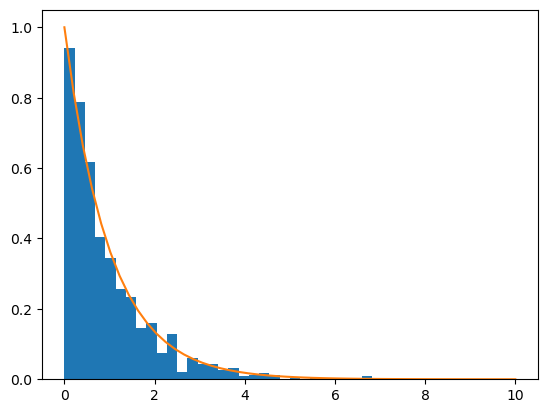

In [17]:
# Traccia l’istogramma del campione e sovrapponi la PDF della distribuzione
plt.hist(sample, bins = 30, density = True)
x = np.linspace(0,10)
plt.plot(x, dist.pdf(x))

In [ ]:
# Stima il parametro di forma dal campione usando il metodo fit.
sp.stats.gamma.fit(sample)  # a noi interessa il primo parametro

(np.float64(0.9644987286057698),
 np.float64(0.0012596243514447986),
 np.float64(0.9877742362039998))

In [ ]:
# Le distribuzioni hanno molti metodi utili. Esplorali usando il completamento automatico con il tasto TAB.


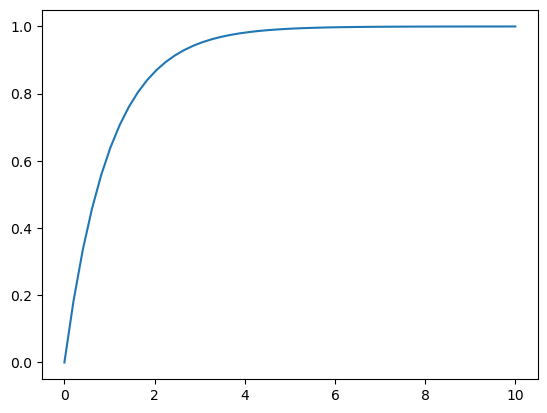

In [20]:
# Traccia la funzione di distribuzione cumulativa (CDF)
cdf = dist.cdf(x)
plt.plot(x, cdf)

In [22]:
# Calcola la varianza
varianza = np.var(sample)
print('varianza: ', varianza)

varianza:  0.9858056355034183


### **2. Fitta i dati**
Prova a fittare i dati sottostanti con le migliori curve, calcola il MAE e l'RMSE
Esercizio 

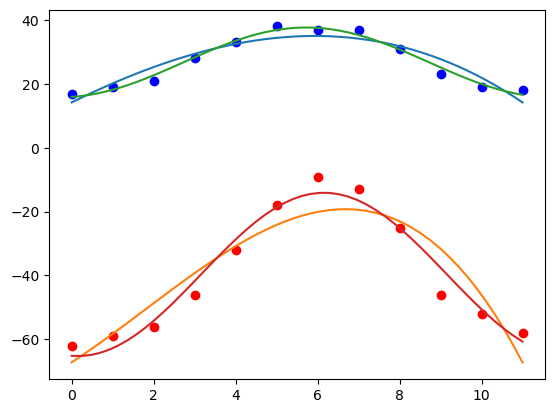

In [28]:
import numpy as np
temp_max = np.array([17, 19, 21, 28, 33, 38, 37, 37, 31, 23, 19, 18])
temp_min = np.array([-62, -59, -56, -46, -32, -18, -9, -13, -25, -46, -52, -58])
import matplotlib.pyplot as plt

months = np.arange(12)
plt.plot(months, temp_max, "bo")
plt.plot(months, temp_min, "ro")

def polinomio_grado_3(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d
params_max, _ = sp.optimize.curve_fit(polinomio_grado_3, months, temp_max)
params_min, _ = sp.optimize.curve_fit(polinomio_grado_3, months, temp_min)

x = np.linspace(0,11)
plt.plot(x, polinomio_grado_3(x, *params_max))
plt.plot(x, polinomio_grado_3(x, *params_min))

def sin(x, a, b, c):
    return c + a*np.sin((x + b)*2*np.pi/12)

params_max, _ = sp.optimize.curve_fit(sin, months, temp_max)
params_min, _ = sp.optimize.curve_fit(sin, months, temp_min)

plt.plot(x, sin(x, *params_max))
plt.plot(x, sin(x, *params_min))

### **3. Modello di regressione lineare dei seguenti dati**

 Calcola un modello di regressione lineare delle colonne mpg e disp del famoso dataset mtcars.

Dove: 

mpg = Miles Per Gallon → miglia per gallone, cioè una misura del consumo di carburante. Più alto è il valore, più efficiente è l’auto.

disp = Displacement → cilindrata del motore, in pollici cubici (cubic inches). Rappresenta il volume totale dei cilindri del motore. Più è alto, maggiore è la potenza potenziale del motore (ma anche il consumo).

In [29]:
import pandas as pd

# Load dataset from URL
df = pd.read_csv('https://gist.githubusercontent.com/seankross/a412dfbd88b3db70b74b/raw/5f23f993cd87c283ce766e7ac6b329ee7cc2e1d1/mtcars.csv')

# Display the dataframe
df


,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2
5,Valiant,18.1,6,225.0,105,2.76,3.460,20.22,1,0,3,1
6,Duster 360,14.3,8,360.0,245,3.21,3.570,15.84,0,0,3,4
7,Merc 240D,24.4,4,146.7,62,3.69,3.190,20.00,1,0,4,2
8,Merc 230,22.8,4,140.8,95,3.92,3.150,22.90,1,0,4,2
9,Merc 280,19.2,6,167.6,123,3.92,3.440,18.30,1,0,4,4


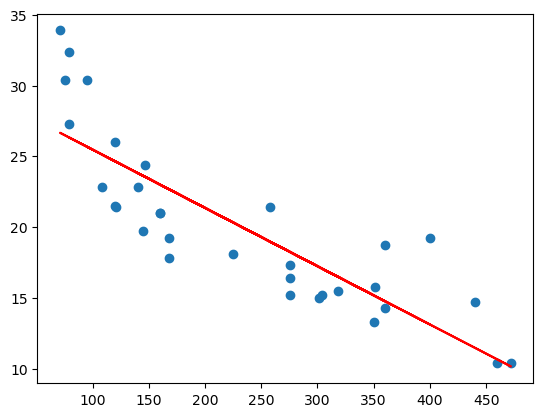

In [32]:
x = df['disp']
y = df['mpg']

slope, intercept, *_ = sp.stats.linregress(x, y)

y_pred = slope*x + intercept

plt.scatter(x, y, label = 'True value')
plt.plot(x, y_pred, label = 'Prediction of y', color = 'red')
